In [ ]:
# HIGH-ACCURACY TRAINING WITH EFFICIENTNET-B3

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
import os
import zipfile
import shutil
from tqdm import tqdm
import time
from collections import Counter
from torch.optim import lr_scheduler

# ---- PATHS & HYPERPARAMS ----
ZIP_FILE_PATH = '/content/gdrive/MyDrive/Nail Diseases 11.zip'
EXTRACT_DIR = '/content/Nail_Diseases_Dataset'
DATA_DIR = os.path.join(EXTRACT_DIR, 'Nail Diseases 11')

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4        # smaller LR for full fine-tuning
PHASES = ['train', 'valid']


def setup_environment():
    """Mounts Google Drive and ensures dataset is extracted and structured correctly."""
    global DATA_DIR

    # Mount Drive (Colab)
    try:
        from google.colab import drive
        print("Mounting Google Drive...")
        drive.mount('/content/gdrive')
        print("Google Drive mounted successfully.")
    except ImportError:
        print("Running outside of Google Colab. Drive mounting skipped.")

    # If main data dir already exists, reuse it
    if not os.path.exists(DATA_DIR):
        print(f"Attempting to unzip {ZIP_FILE_PATH}...")
        try:
            os.makedirs(EXTRACT_DIR, exist_ok=True)
            with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
                zip_ref.extractall(EXTRACT_DIR)
            print(f"Dataset extracted to {EXTRACT_DIR}.")
        except FileNotFoundError:
            print(f"ERROR: Zip file not found at {ZIP_FILE_PATH}. Please check the path and file name.")
            return False
        except Exception as e:
            print(f"An error occurred during unzipping: {e}")
            return False
    else:
        print(f"✅ Dataset directory already exists at: {DATA_DIR}")

    # Adjust DATA_DIR if needed
    if not os.path.exists(DATA_DIR):
        print(f"WARNING: Expected data directory {DATA_DIR} not found.")
        extracted_content = os.listdir(EXTRACT_DIR)
        print(f"Content in {EXTRACT_DIR}: {extracted_content}")

        if len(extracted_content) == 1 and os.path.isdir(os.path.join(EXTRACT_DIR, extracted_content[0])):
            DATA_DIR = os.path.join(EXTRACT_DIR, extracted_content[0])
            print(f"Adjusted DATA_DIR to: {DATA_DIR}")
        else:
            print("ERROR: Could not automatically determine the correct data directory structure.")
            return False

    # Check train/valid existence
    if not os.path.isdir(os.path.join(DATA_DIR, 'train')) or \
       not os.path.isdir(os.path.join(DATA_DIR, 'valid')):
        print(f"ERROR: Expected 'train' and 'valid' subdirectories inside {DATA_DIR} were not found.")
        print("Please ensure your extracted folder structure is like: .../train/class_A, .../valid/class_A, etc.")
        return False

    return True


def prepare_data_loaders(data_dir, batch_size=32):
    """
    Creates dataloaders from 'train' and 'valid' subdirectories.
    Uses LIGHT transforms because dataset is already augmented via Roboflow.
    """
    print("\nPreparing data loaders from pre-split directories ('train' and 'valid')...")

    # Remove any stray 'images' folder that Roboflow sometimes leaves
    for phase in PHASES:
        split_dir = os.path.join(data_dir, phase)
        unwanted_dir = os.path.join(split_dir, 'images')
        if os.path.isdir(unwanted_dir):
            shutil.rmtree(unwanted_dir)
            print(f"Removed extraneous '{phase}/images' folder from data directory.")

    # LIGHT transforms (no extra strong aug; Roboflow already did it)
    data_transforms = {
        'train': transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(p=0.3),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ]),
        'valid': transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ]),
    }

    image_datasets = {
        x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
        for x in PHASES
    }

    # num_workers: 2 is safer in Colab to avoid the warning
    num_workers_setting = 2 if torch.cuda.is_available() else 0

    dataloaders = {
        'train': DataLoader(
            image_datasets['train'],
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers_setting,
            pin_memory=True
        ),
        'valid': DataLoader(
            image_datasets['valid'],
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers_setting,
            pin_memory=True
        )
    }

    class_names = image_datasets['train'].classes

    # Class distribution (for info)
    train_counts = Counter(image_datasets['train'].targets)
    valid_counts = Counter(image_datasets['valid'].targets)

    idx_to_class = {v: k for k, v in image_datasets['train'].class_to_idx.items()}
    train_dist = {idx_to_class[k]: v for k, v in train_counts.items()}
    val_dist = {idx_to_class[k]: v for k, v in valid_counts.items()}

    print(f"Found {len(class_names)} classes: {class_names}")
    print(f"Training Samples: {len(image_datasets['train'])}. Validation Samples: {len(image_datasets['valid'])}")
    print("Train Class Distribution (Class: Count):", train_dist)
    print("Validation Class Distribution (Class: Count):", val_dist)

    return dataloaders, class_names


def get_model(num_classes):
    """Loads a pre-trained EfficientNet-B3 and replaces the final layer for full fine-tuning."""
    print("\nLoading pre-trained EfficientNet-B3 model...")
    # Pretrained EfficientNet-B3
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)

    # Replace classifier head
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    # IMPORTANT: we do NOT freeze the backbone; we fine-tune the whole network
    for param in model.parameters():
        param.requires_grad = True

    print(f"Model modified for Fine-Tuning, classifying {num_classes} classes.")
    return model


def train_model(model, dataloaders, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE):
    """Runs the training and validation loop with Early Stopping and LR Scheduling."""
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"\nUsing device: {device}")
    model = model.to(device)

    # ---- CLASS-WEIGHTED LOSS (handles imbalance a bit better) ----
    train_dataset = dataloaders['train'].dataset
    targets = train_dataset.targets
    class_counts = Counter(targets)
    num_classes = len(class_counts)
    class_sample_counts = [class_counts[i] for i in range(num_classes)]
    class_weights = 1.0 / torch.tensor(class_sample_counts, dtype=torch.float)
    class_weights = class_weights.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # Fine-tune ALL parameters
    optimizer = optim.AdamW(model.parameters(), lr=lr)

    # LR scheduler based on validation loss
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1)

    best_acc = 0.0
    best_val_loss = float('inf')
    epochs_no_improve = 0
    patience = 7

    since = time.time()

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in PHASES:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloaders[phase], desc=f"{phase.upper()} Phase"):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'valid':
                scheduler.step(epoch_loss)

                # Early stopping based on validation loss, but save best model by accuracy
                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    epochs_no_improve = 0

                    if epoch_acc > best_acc:
                        best_acc = epoch_acc
                        torch.save(model.state_dict(), 'best_nail_classifier_model.pth')
                        print("--- Saved best model state dict based on Acc! ---")
                else:
                    epochs_no_improve += 1

                if epochs_no_improve >= patience:
                    print(f'\nEarly stopping triggered after {patience} epochs with no improvement in validation loss.')
                    time_elapsed = time.time() - since
                    print(f'Training stopped at epoch {epoch+1} in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
                    model.load_state_dict(torch.load('best_nail_classifier_model.pth'))
                    return model

    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Valid Acc: {best_acc:.4f}')

    model.load_state_dict(torch.load('best_nail_classifier_model.pth'))
    return model


# ---- MAIN ----
if __name__ == '__main__':
    if not setup_environment():
        print("Setup failed. Please check your ZIP file path, file structure, and try again.")
    else:
        dataloaders, class_names = prepare_data_loaders(
            data_dir=DATA_DIR,
            batch_size=BATCH_SIZE
        )

        actual_num_classes = len(class_names)
        model_ft = get_model(num_classes=actual_num_classes)

        final_model = train_model(
            model=model_ft,
            dataloaders=dataloaders,
            num_epochs=NUM_EPOCHS,
            lr=LEARNING_RATE
        )

        class_to_idx = datasets.ImageFolder(os.path.join(DATA_DIR, 'train')).class_to_idx

        print("\nModel trained successfully!")
        print("Class Mapping (Class Name: Index):")
        print(class_to_idx)
        print("\nTo load and use the best model later, run:")
        print("model.load_state_dict(torch.load('best_nail_classifier_model.pth'))")

Mounting Google Drive...
Mounted at /content/gdrive
Google Drive mounted successfully.
Attempting to unzip /content/gdrive/MyDrive/Nail Diseases 11.zip...
Dataset extracted to /content/Nail_Diseases_Dataset.

Preparing data loaders from pre-split directories ('train' and 'valid')...
Found 8 classes: ['Acral Lentiginous Melanoma', 'Beau’s Lines', 'Bluish Nail', 'Clubbing', 'Healthy Nail', 'Koilonychia', 'Onychogryphosis', 'Pitting']
Training Samples: 15390. Validation Samples: 479
Train Class Distribution (Class: Count): {'Acral Lentiginous Melanoma': 2259, 'Beau’s Lines': 1368, 'Bluish Nail': 1836, 'Clubbing': 2349, 'Healthy Nail': 1926, 'Koilonychia': 1611, 'Onychogryphosis': 2070, 'Pitting': 1971}
Validation Class Distribution (Class: Count): {'Acral Lentiginous Melanoma': 70, 'Beau’s Lines': 44, 'Bluish Nail': 59, 'Clubbing': 74, 'Healthy Nail': 54, 'Koilonychia': 52, 'Onychogryphosis': 65, 'Pitting': 61}

Loading pre-trained EfficientNet-B3 model...
Downloading: "https://download.p

100%|██████████| 47.2M/47.2M [00:00<00:00, 106MB/s]


Model modified for Fine-Tuning, classifying 8 classes.

Using device: cuda:0

Epoch 1/50
----------


TRAIN Phase: 100%|██████████| 481/481 [02:26<00:00,  3.29it/s]


Train Loss: 0.7283 Acc: 0.7722


...

Valid Loss: 0.4245 Acc: 0.8914

Epoch 11/50
----------


TRAIN Phase: 100%|██████████| 481/481 [02:34<00:00,  3.10it/s]


Train Loss: 0.0066 Acc: 0.9984


VALID Phase: 100%|██████████| 15/15 [00:01<00:00, 10.33it/s]


Valid Loss: 0.3858 Acc: 0.8977

Early stopping triggered after 7 epochs with no improvement in validation loss.
Training stopped at epoch 11 in 28m 27s

Model trained successfully!
Class Mapping (Class Name: Index):
{'Acral Lentiginous Melanoma': 0, 'Beau’s Lines': 1, 'Bluish Nail': 2, 'Clubbing': 3, 'Healthy Nail': 4, 'Koilonychia': 5, 'Onychogryphosis': 6, 'Pitting': 7}

To load and use the best model later, run:
model.load_state_dict(torch.load('best_nail_classifier_model.pth'))


In [ ]:
import torch
from torchvision import transforms, models
from PIL import Image
import os
from sklearn.metrics import classification_report, accuracy_score
import torch.nn as nn

# ✅ Adjust this path if your test folder is elsewhere
MODEL_PATH = "/content/best_nail_classifier_model.pth"
TEST_IMAGES_DIR = "/content/Nail_Diseases_Dataset/Nail Diseases 11/test"

# 🔹 Automatically detect class names from test directory
class_names = sorted([
    d for d in os.listdir(TEST_IMAGES_DIR)
    if os.path.isdir(os.path.join(TEST_IMAGES_DIR, d))
])

print("Detected classes:", class_names)

num_classes = len(class_names)

# ✅ Rebuild model with correct output size
model = models.efficientnet_b3(weights=None)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

state_dict = torch.load(MODEL_PATH, map_location="cpu")
model.load_state_dict(state_dict)
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def predict_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img_t = transform(img).unsqueeze(0)
    with torch.no_grad():
        outputs = model(img_t)
        _, pred = torch.max(outputs, 1)
    return pred.item()


y_true = []
y_pred = []

print("\n========================")
print("      TEST EVALUATION")
print("========================\n")

for class_index, cls in enumerate(class_names):
    folder_path = os.path.join(TEST_IMAGES_DIR, cls)
    images = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"Testing: {cls} ({len(images)} images)")

    for img_name in images:
        img_path = os.path.join(folder_path, img_name)
        pred_idx = predict_image(img_path)
        y_true.append(class_index)
        y_pred.append(pred_idx)

print("\n===================================")
print("       CLASSIFICATION REPORT")
print("===================================\n")

print(classification_report(y_true, y_pred, target_names=class_names))

acc = accuracy_score(y_true, y_pred)
print(f"\nOverall TEST accuracy: {acc * 100:.2f}%")

Detected classes: ['Acral Lentiginous Melanoma', 'Beau’s Lines', 'Bluish Nail', 'Clubbing', 'Healthy Nail', 'Koilonychia', 'Onychogryphosis', 'Pitting']

      TEST EVALUATION

Testing: Acral Lentiginous Melanoma (36 images)
Testing: Beau’s Lines (22 images)
Testing: Bluish Nail (29 images)
Testing: Clubbing (38 images)
Testing: Healthy Nail (30 images)
Testing: Koilonychia (28 images)
Testing: Onychogryphosis (34 images)
Testing: Pitting (32 images)

       CLASSIFICATION REPORT

                            precision    recall  f1-score   support

Acral Lentiginous Melanoma       1.00      0.92      0.96        36
              Beau’s Lines       0.75      0.95      0.84        22
               Bluish Nail       0.96      0.90      0.93        29
                  Clubbing       0.81      0.89      0.85        38
              Healthy Nail       0.93      0.93      0.93        30
               Koilonychia       0.95      0.71      0.82        28
           Onychogryphosis       0.97


🔮 Predicted Class: Koilonychia


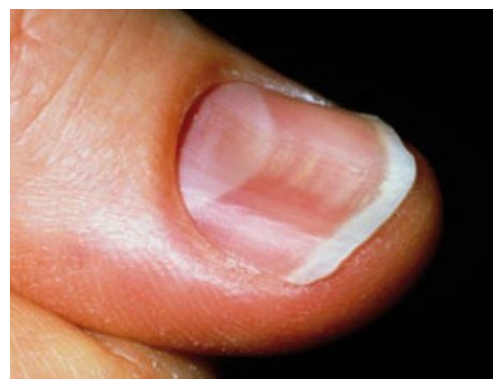

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

img_path = "/content/testimage13.jpg"

img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')

pred_idx = predict_image(img_path)
print("\n🔮 Predicted Class:", class_names[pred_idx])


🔮 Predicted Class: Healthy Nail


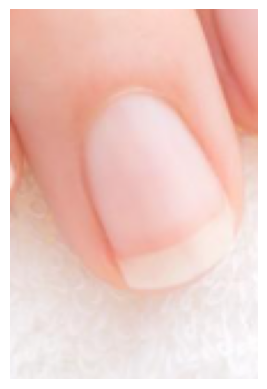

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

img_path = "/content/testimage17.png"

img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')

pred_idx = predict_image(img_path)
print("\n🔮 Predicted Class:", class_names[pred_idx])


🔮 Predicted Class: Bluish Nail


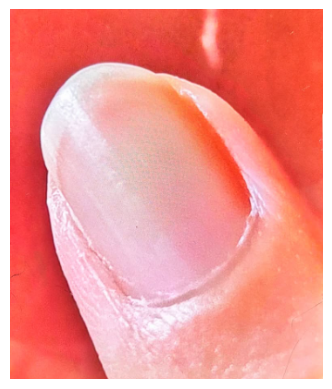

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

img_path = "/content/testingimage18.png"

img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')

pred_idx = predict_image(img_path)
print("\n🔮 Predicted Class:", class_names[pred_idx])